In [29]:
import ast
import math
import powerlaw
from collections import Counter

import pandas as pd
import numpy as np

import networkx as nx
from networkx.algorithms.cuts import conductance

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

import igraph as ig
from ipysigma import Sigma

from IPython.display import display

from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline

In [44]:
graph_nx = nx.read_graphml("graphs/ingredient_network_light.graphml")
for n in graph_nx.nodes:
    graph_nx.nodes[n]["recipe_count_log"] = np.log1p(graph_nx.nodes[n]["recipe_count"])
graph = ig.Graph.from_networkx(graph_nx)

## 1. Graph Visualization

In [10]:
def normalize_layout(layout):
    pts = [(p[0], p[1]) for p in layout]
    cx = sum(x for x, y in pts) / len(pts)
    cy = sum(y for x, y in pts) / len(pts)

    pts = [(x - cx, y - cy) for x, y in pts]
    max_r = max(math.sqrt(x*x + y*y) for x, y in pts) or 1

    return [(x / max_r, y / max_r) for x, y in pts]

In [11]:
components = graph.connected_components(mode="weak")
components = sorted(components, key=len, reverse=True)

giant_component = components[0]
small_components = components[1:]

In [5]:
coords = [(0.0, 0.0)] * graph.vcount()

giant_subgraph = graph.subgraph(giant_component)
giant_layout = giant_subgraph.layout_drl()
giant_layout = normalize_layout(giant_layout)

giant_radius = 330

for i, v in enumerate(giant_component):
    x, y = giant_layout[i]
    coords[v] = (x * giant_radius, y * giant_radius)

ring_radius = 460

for k, component in enumerate(small_components):
    angle = 2 * math.pi * k / len(small_components)
    center_x = math.cos(angle) * ring_radius
    center_y = math.sin(angle) * ring_radius

    subgraph = graph.subgraph(component)

    if subgraph.vcount() == 1:
        local_layout = [(0, 0)]
    else:
        local_layout = subgraph.layout_fruchterman_reingold(niter=200)
        local_layout = normalize_layout(local_layout)

    component_radius = 12 + math.sqrt(len(component)) * 4

    for i, v in enumerate(component):
        x, y = local_layout[i]
        coords[v] = (
            center_x + x * component_radius,
            center_y + y * component_radius
        )

layout = ig.Layout(coords)
layout.fit_into((0, 0, 1000, 1000))

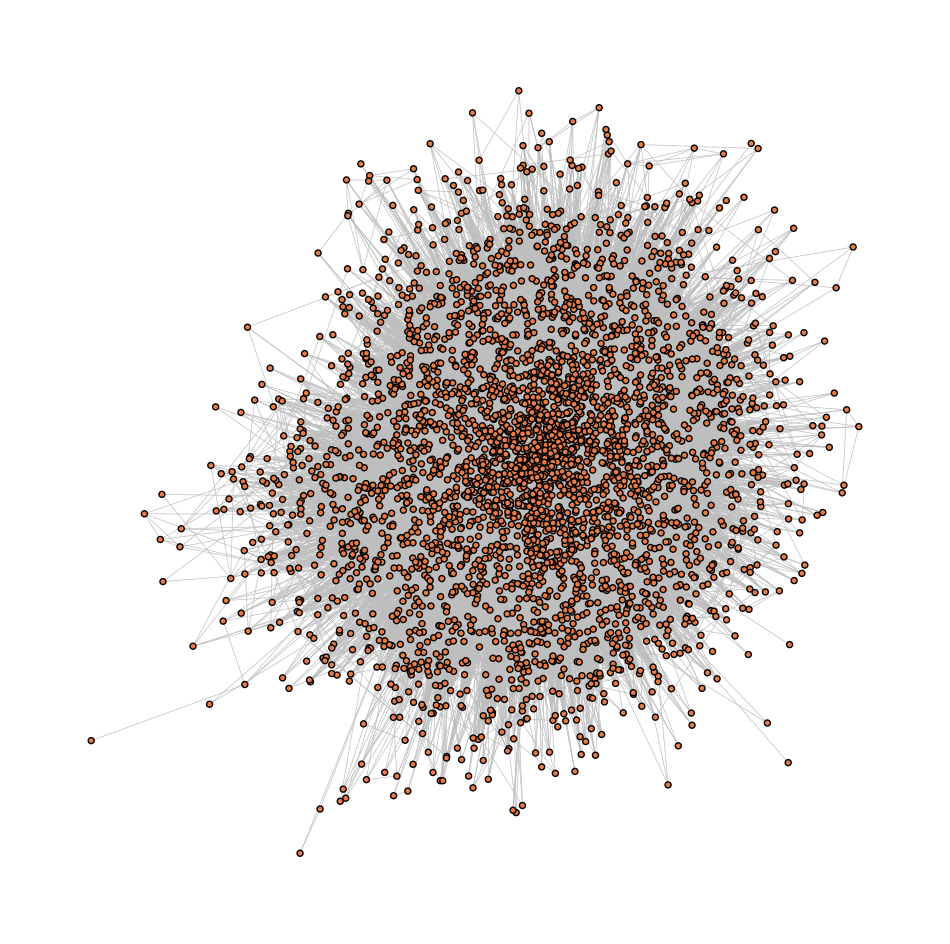

In [6]:
# Visualize the graph
layout = graph.layout_fruchterman_reingold(niter=1000)

fig, ax = plt.subplots(figsize=(12, 12))

ig.plot(
    graph,
    target=ax,
    layout=layout,
    vertex_size=6,
    vertex_label=None,
    vertex_color="#E87C47",
    edge_width=0.5,
    edge_color="gray",
)

plt.show()

In [85]:
Sigma(
    graph, 
    node_size="recipe_count", 
    node_color="recipe_count_log",
    node_color_gradient=("blue", "red"), 
    node_label="_nx_name"
)

Sigma(ig.Graph with 3,611 nodes and 130,439 edges)

## 2. Statistics

#### 2.1 Vertex Degree Distribution

,degree,vertex_count
0,1,4
1,2,13
2,3,46
3,4,76
4,5,106


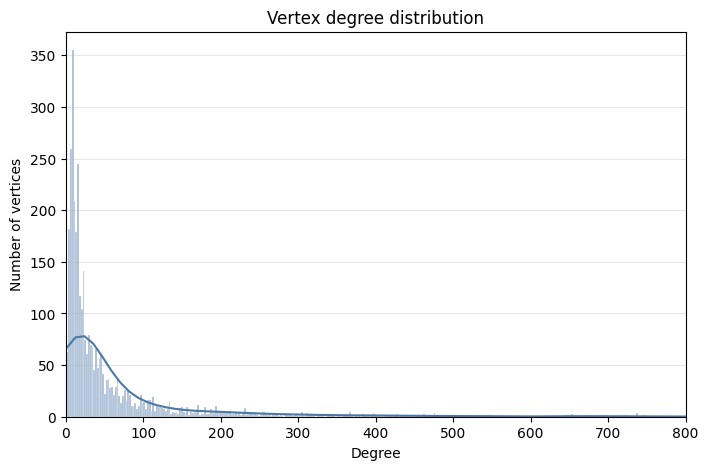

In [8]:
degrees = graph.degree()

degree_counts = pd.Series(degrees).value_counts().sort_index()
degree_distribution = pd.DataFrame({
    "degree": degree_counts.index,
    "vertex_count": degree_counts.values,
})
display(degree_distribution.head())

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    degrees,
    bins=1000,
    kde=True,
    stat="count",
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.2,
    ax=ax,
)
ax.set_title("Vertex degree distribution")
ax.set_xlabel("Degree")
ax.set_ylabel("Number of vertices")
ax.set_xlim(left=0, right=800)
ax.grid(axis="y", alpha=0.3)

plt.show()

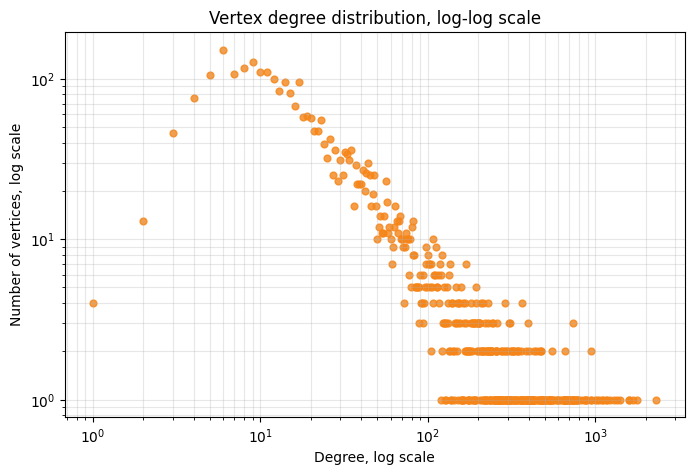

In [9]:
positive_degree_distribution = degree_distribution[degree_distribution["degree"] > 0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    positive_degree_distribution["degree"],
    positive_degree_distribution["vertex_count"],
    s=24,
    alpha=0.8,
    color="#F58518",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Vertex degree distribution, log-log scale")
ax.set_xlabel("Degree, log scale")
ax.set_ylabel("Number of vertices, log scale")
ax.grid(True, which="both", alpha=0.3)

plt.show()

In [10]:
degrees = [d for d in graph.degree() if d > 0]

fit = powerlaw.Fit(degrees, discrete=True)
print("xmin:", fit.power_law.xmin)
print("alpha:", fit.power_law.alpha)

R, p = fit.distribution_compare("power_law", "lognormal")
print("power-law vs lognormal:", R, p)

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 427/427 [00:00<00:00, 1341.05it/s]

xmin: 192.0
alpha: 2.6127500556032066
power-law vs lognormal: -7.837429463206794 0.01358152249285974


#### 2.2 Average Vertex Degree and Edge Density

In [86]:
avg_degree = sum(degrees) / len(degrees)
density = avg_degree / (len(degrees) - 1)

print(f"Average degree: {avg_degree}")
print(f"Edge density: {density}")

Average degree: 72.24536139573526
Edge density: 0.020012565483583173


#### 2.3 Clustering Coefficients

In [56]:
def parse_counter_attr(value):
    if isinstance(value, dict):
        return Counter(value)
    if value is None or value == "":
        return Counter()
    return Counter(ast.literal_eval(value))

def parse_cuisines(x):
    if isinstance(x, dict):
        return x
    return ast.literal_eval(x)

In [57]:
def add_pmi_edge_weights(graph_nx, total_recipe_count, count_weight="recipe_count"):
    graph_with_pmi = graph_nx.copy()

    for u, v, attrs in graph_with_pmi.edges(data=True):
        pair_count = float(attrs[count_weight])  # num of pairs (u, v)
        u_count = float(graph_with_pmi.nodes[u][count_weight])  # num of recipes with an ingredient u
        v_count = float(graph_with_pmi.nodes[v][count_weight])  # num of recipes with an ingredient v

        pmi = math.log((pair_count * total_recipe_count) / (u_count * v_count))
        attrs["pmi"] = pmi
        attrs["positive_pmi"] = max(pmi, 0)

    return graph_with_pmi

In [58]:
total_recipe_count = int(graph_nx.graph.get("total_recipes", 7034))

edge_weight_name = "positive_pmi"
pmi_graph_nx = add_pmi_edge_weights(graph_nx, total_recipe_count)
pmi_graph = ig.Graph.from_networkx(pmi_graph_nx)
pmi_edge_weights = [float(weight) for weight in pmi_graph.es[edge_weight_name]]

##### 1. Unweighted

In [59]:
global_clustering = graph.transitivity_undirected()
average_local_clustering = graph.transitivity_avglocal_undirected(mode="zero")
local_clustering = graph.transitivity_local_undirected(mode="zero")

print("Global clustering coefficient:", global_clustering)
print("Average local clustering coefficient:", average_local_clustering)

clustering_by_vertex = pd.DataFrame({
    "ingredient": graph.vs["_nx_name"],
    "degree": graph.degree(),
    "clustering_coefficient": local_clustering,
})

display(clustering_by_vertex.sort_values(["clustering_coefficient", "degree"], ascending=[False, False]).head(10))

Global clustering coefficient: 0.21953796667757247
Average local clustering coefficient: 0.7550503733770957


,ingredient,degree,clustering_coefficient
1222,asafoetida powder,34,1.0
1870,dal,34,1.0
820,dukkah,32,1.0
3574,sourdough,32,1.0
1999,annatto,30,1.0
2082,sweet italian pork sausage,28,1.0
758,dried date,25,1.0
1109,barramundi,25,1.0
434,dark turkey meat,24,1.0
749,japanese mountain yam,24,1.0


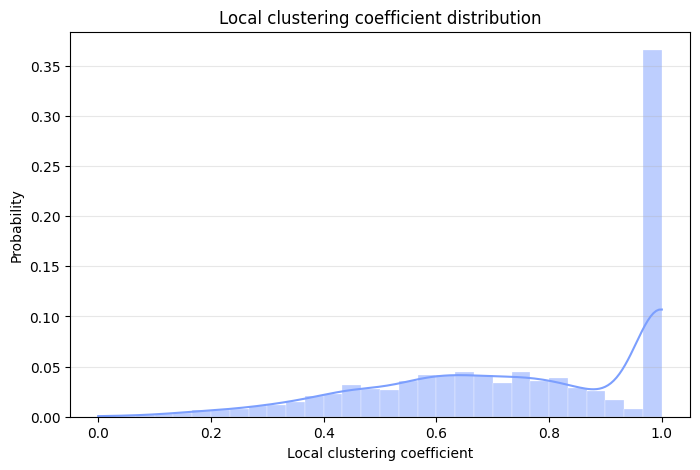

In [67]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    clustering_by_vertex["clustering_coefficient"],
    bins=30,
    kde=True,
    color="#7C9FFE",
    edgecolor="white",
    linewidth=0.2,
    ax=ax,
    stat="probability"
)
ax.set_title("Local clustering coefficient distribution")
ax.set_xlabel("Local clustering coefficient")
# ax.set_ylabel("Number of vertices")
ax.set_ylabel("Probability")
ax.grid(axis="y", alpha=0.3)

plt.show()

##### 2. Weighted (weight = PPMI)

In [65]:
weighted_average_local_clustering = pmi_graph.transitivity_avglocal_undirected(mode="zero", weights=edge_weight_name)
weighted_local_clustering = pmi_graph.transitivity_local_undirected(mode="zero", weights=edge_weight_name)

print("Weighted average local clustering coefficient:", weighted_average_local_clustering)

weighted_clustering_by_vertex = pd.DataFrame({
    "ingredient": pmi_graph.vs["_nx_name"],
    "degree": pmi_graph.degree(),
    "weighted_degree": pmi_graph.strength(weights=edge_weight_name),
    "clustering_coefficient": weighted_local_clustering,
})

display(weighted_clustering_by_vertex.sort_values(["clustering_coefficient", "degree"], ascending=[False, False]).head(10))

Weighted average local clustering coefficient: 0.6930024528284374


,ingredient,degree,weighted_degree,clustering_coefficient
1197,pork bones,21,94.075440,1.0
1121,millet,20,91.441205,1.0
3060,cubed pumpkin,20,91.441205,1.0
1219,mazola® sobrecitos™ chicken flavor bouillon pa...,17,106.112636,1.0
1662,spice islands® minced garlic,17,106.112636,1.0
1899,spice islands bay leaves,17,106.112636,1.0
2653,spice islands ground cumin seed,17,106.112636,1.0
3415,spice islands medium grind black pepper,17,106.112636,1.0
1256,curcuma,14,75.895020,1.0
749,japanese mountain yam,24,92.778228,1.0


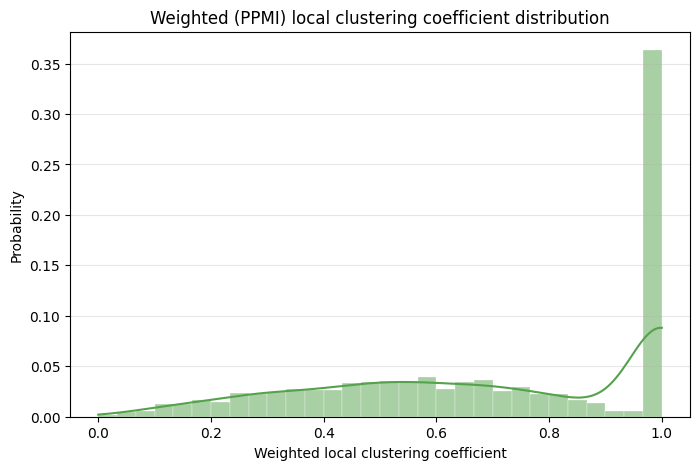

In [116]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    weighted_clustering_by_vertex["clustering_coefficient"],
    bins=30,
    kde=True,
    color="#54A24B",
    edgecolor="white",
    linewidth=0.2,
    ax=ax,
    stat="probability"
)
ax.set_title("Weighted (PPMI) local clustering coefficient distribution")
ax.set_xlabel("Weighted local clustering coefficient")
# ax.set_ylabel("Number of vertices")
ax.set_ylabel("Probability")
ax.grid(axis="y", alpha=0.3)

plt.show()

#### 2.4 Community Detection

In [ ]:
def sparsify_top_k(graph_nx, top_k=10, weight="positive_pmi", min_weight=0, min_cooccurrence=1):
    sparse_nx = nx.Graph()
    sparse_nx.add_nodes_from(graph_nx.nodes(data=True))

    edges_to_keep = set()
    for node in graph_nx.nodes:
        neighbors = [
            (neighbor, edge_attrs)
            for neighbor, edge_attrs in graph_nx[node].items()
            if int(edge_attrs.get("recipe_count", 0)) >= min_cooccurrence
        ]
        neighbors = sorted(neighbors, key=lambda item: float(item[1].get(weight, 1)), reverse=True)
        selected_neighbors = neighbors if top_k is None or top_k <= 0 else neighbors[:top_k]

        for neighbor, edge_attrs in selected_neighbors:
            if float(edge_attrs[weight]) >= min_weight:
                edges_to_keep.add(frozenset((node, neighbor)))

    for u, v, edge_attrs in graph_nx.edges(data=True):
        if frozenset((u, v)) in edges_to_keep:
            edge_attrs = edge_attrs.copy()
            edge_attrs[weight] = float(edge_attrs[weight])
            sparse_nx.add_edge(u, v, **edge_attrs)

    return sparse_nx

In [96]:
def top_ppmi_edges(graph_nx, min_cooccurrence, nodes=None, top_n=20):
    node_set = set(nodes) if nodes is not None else None
    rows = []

    for u, v, attrs in graph_nx.edges(data=True):
        if node_set is not None and (u not in node_set or v not in node_set):
            continue

        cooccurrence = int(attrs.get("recipe_count", 0))
        if cooccurrence < min_cooccurrence:
            continue
        
        cuisines = parse_cuisines(attrs.get("cuisines"))
        specific_cuisine = max(cuisines, key = cuisines.get)
        courses = parse_cuisines(attrs.get("courses"))
        specific_course = max(courses, key = courses.get)

        rows.append({
            "ingredient_1": u,
            "ingredient_2": v,
            "positive_pmi": float(attrs[edge_weight_name]),
            "recipe_count": cooccurrence,
            "specific_cuisine": specific_cuisine,
            "specific_course": specific_course
        })

    columns = ["ingredient_1", "ingredient_2", "positive_pmi", "recipe_count", "specific_cuisine", "specific_course"]
    if not rows:
        return pd.DataFrame(columns=columns)

    return (
        pd.DataFrame(rows, columns=columns)
        .sort_values(["positive_pmi", "recipe_count"], ascending=[False, False])
        .head(top_n)
        .reset_index(drop=True)
    )

In [118]:
top_k_neighbors = None
min_edge_weight = 0
min_component_size = 5
max_general_recipe_count = 100
min_cooccurence = 3

In [119]:
general_ingredient_nodes = [
    node
    for node, attrs in pmi_graph_nx.nodes(data=True)
    if int(attrs["recipe_count"]) > max_general_recipe_count
]
general_ingredient_columns = ["ingredient", "degree", "recipe_count"]
general_ingredient_df = pd.DataFrame([
    {
        "ingredient": node,
        "degree": pmi_graph_nx.degree(node),
        "recipe_count": int(pmi_graph_nx.nodes[node]["recipe_count"]),
    }
    for node in general_ingredient_nodes
], columns=general_ingredient_columns).sort_values(["recipe_count", "degree"], ascending=[False, False]).reset_index(drop=True)

pmi_community_nx = pmi_graph_nx.copy()
pmi_community_nx.remove_nodes_from(general_ingredient_nodes)

In [120]:
raw_sparse_nx = sparsify_top_k(
    pmi_community_nx,
    top_k=top_k_neighbors,
    weight=edge_weight_name,
    min_weight=min_edge_weight,
    min_cooccurrence=min_cooccurence,
)

large_components = [component for component in nx.connected_components(raw_sparse_nx) if len(component) >= min_component_size]
nodes_to_keep = set().union(*large_components) if large_components else set(raw_sparse_nx.nodes)

sparse_nx = raw_sparse_nx.subgraph(nodes_to_keep).copy()

In [121]:
pmi_core_nx = pmi_community_nx.subgraph(nodes_to_keep).copy()
pmi_core_graph = ig.Graph.from_networkx(pmi_core_nx)
pmi_core_edge_weights = [float(weight) for weight in pmi_core_graph.es[edge_weight_name]]

In [122]:
sparse_graph = ig.Graph.from_networkx(sparse_nx)
edge_weights = [float(weight) for weight in sparse_graph.es[edge_weight_name]]

print("Original graph:", graph_nx.number_of_nodes(), "nodes,", graph_nx.number_of_edges(), "edges")
print("Removed general ingredients:", len(general_ingredient_nodes), f"(recipe_count > {max_general_recipe_count})")
print("Raw sparse graph:", raw_sparse_nx.number_of_nodes(), "nodes,", raw_sparse_nx.number_of_edges(), "edges")
print("Removed from small components:", raw_sparse_nx.number_of_nodes() - sparse_nx.number_of_nodes(), "nodes")
print("Sparse graph:", sparse_nx.number_of_nodes(), "nodes,", sparse_nx.number_of_edges(), "edges")
print("Connected components:", nx.number_connected_components(sparse_nx))

Original graph: 3611 nodes, 130439 edges
Removed general ingredients: 143 (recipe_count > 100)
Raw sparse graph: 3468 nodes, 3396 edges
Removed from small components: 2621 nodes
Sparse graph: 847 nodes, 3387 edges
Connected components: 1


In [123]:
MIN_EDGE_COOCCURRENCE = 10

top_ppmi_edge_df = top_ppmi_edges(sparse_nx, min_cooccurrence=MIN_EDGE_COOCCURRENCE, top_n=30)
display(top_ppmi_edge_df)

,ingredient_1,ingredient_2,positive_pmi,recipe_count,specific_cuisine,specific_course
0,crush,dri oregano leaves,6.150461,12,mediterranean,main dishes
1,lettuce leaves,swordfish,5.813988,10,barbecue,main dishes
2,roast red peppers,drain,5.680457,15,mediterranean,main dishes
3,nori,sushi rice,5.303163,12,asian,main dishes
4,ginger paste,garlic paste,4.668856,13,indian,main dishes
5,ricotta cheese,lasagna noodles,4.653108,21,italian,main dishes
6,galangal,kaffir lime leaves,4.652941,17,asian,soups
7,coriander powder,red chili powder,4.525755,13,indian,main dishes
8,egg noodles,cooked and drained,4.267440,10,hungarian,main dishes
9,red chili powder,garlic paste,4.191647,11,indian,main dishes


In [179]:
communities = sparse_graph.community_leiden(objective_function="modularity", weights=edge_weight_name, n_iterations=-1)
membership = communities.membership
sparse_graph.vs["community"] = membership

graph_nx_communities = dict(zip(sparse_graph.vs["_nx_name"], membership))
nx.set_node_attributes(sparse_nx, graph_nx_communities, "community")

# pmi_membership = [graph_nx_communities[name] for name in pmi_graph.vs["_nx_name"]]
pmi_core_membership = [graph_nx_communities[name] for name in pmi_core_graph.vs["_nx_name"]]

print("Communities:", len(communities))

print()
print("Modularity:")
# print(f"\tInitial graph - {pmi_graph_nx.number_of_nodes()} nodes, {pmi_graph_nx.number_of_edges()}) edges:", pmi_graph.modularity(pmi_membership, weights=edge_weight_name))
# print(f"\tsparse graph used for Leiden: {sparse_graph.vcount()} nodes, {sparse_graph.ecount()} edges:", sparse_graph.modularity(membership, weights=edge_weight_name))
print(f"\t- {pmi_core_graph.vcount()} nodes, but edges ({pmi_core_graph.ecount()}) are kept:", pmi_core_graph.modularity(pmi_core_membership, weights=edge_weight_name))
print(f"\t- Sparse graph used for Leiden - {sparse_graph.vcount()} nodes, {sparse_graph.ecount()} edges:", sparse_graph.modularity(membership, weights=edge_weight_name))

Communities: 15

Modularity:
	- 847 nodes, but edges (24081) are kept: 0.27995271176054176
	- Sparse graph used for Leiden - 847 nodes, 3387 edges: 0.6600441470210081


In [183]:
weighted_degree = sparse_graph.strength(weights=edge_weights)
ingredient_communities = pd.DataFrame({
    "ingredient": sparse_graph.vs["_nx_name"],
    "community": membership,
    "degree": sparse_graph.degree(),
    "weighted_degree": weighted_degree,
    "recipe_count": [int(v["recipe_count"]) for v in sparse_graph.vs],
})

global_cuisine_counts = Counter()
for vertex in sparse_graph.vs:
    global_cuisine_counts.update(parse_counter_attr(vertex["cuisines"]))
global_cuisine_total = sum(global_cuisine_counts.values())

community_rows = []
for community_id in sorted(set(membership)):
    vertex_indices = [idx for idx, value in enumerate(membership) if value == community_id]
    community_df = (
        ingredient_communities[ingredient_communities["community"] == community_id]
        .sort_values("weighted_degree", ascending=False)
    )
    community_nodes = community_df["ingredient"].tolist()
    top_community_edges = top_ppmi_edges(
        pmi_core_nx,
        nodes=community_nodes,
        min_cooccurrence=MIN_EDGE_COOCCURRENCE,
        top_n=6,
    )

    cuisine_counts = Counter()
    course_counts = Counter()
    for vertex_idx in vertex_indices:
        cuisine_counts.update(parse_counter_attr(sparse_graph.vs[vertex_idx]["cuisines"]))
        course_counts.update(parse_counter_attr(sparse_graph.vs[vertex_idx]["courses"]))

    cuisine_total = sum(cuisine_counts.values())
    course_total = sum(course_counts.values())
    dominant_cuisine, dominant_cuisine_count = cuisine_counts.most_common(1)[0] if cuisine_counts else (None, 0)
    dominant_course, dominant_course_count = course_counts.most_common(1)[0] if course_counts else (None, 0)

    cuisine_lifts = {
        cuisine: (count / cuisine_total) / (global_cuisine_counts[cuisine] / global_cuisine_total)
        for cuisine, count in cuisine_counts.items()
        if cuisine_total > 0 and global_cuisine_counts[cuisine] > 0 and count >= 3
    }
    specific_cuisine, specificity_lift = (
        max(cuisine_lifts.items(), key=lambda item: item[1])
        if cuisine_lifts else (None, float("nan"))
    )

    community_rows.append({
        "community": community_id,
        "size": len(vertex_indices),
        # "internal_edges": sparse_graph.subgraph(vertex_indices).ecount(),
        "dominant_cuisine": dominant_cuisine,
        "dominant_cuisine_share": dominant_cuisine_count / cuisine_total if cuisine_total else 0,
        "specific_cuisine": specific_cuisine,
        # "specificity_lift": specificity_lift,
        "dominant_course": dominant_course,
        "dominant_course_share": dominant_course_count / course_total if course_total else 0,
        "central_ingredients": ", ".join(community_df["ingredient"].head(6)),
        "top_ppmi_pairs": "; ".join(f"{row.ingredient_1} + {row.ingredient_2} (PPMI={row.positive_pmi:.2f}, n={row.recipe_count})"
                                    for row in top_community_edges.itertuples(index=False)),
    })

community_summary = pd.DataFrame(community_rows).sort_values("size", ascending=False).reset_index(drop=True)
display(community_summary)

,community,size,dominant_cuisine,dominant_cuisine_share,specific_cuisine,dominant_course,dominant_course_share,central_ingredients,top_ppmi_pairs
0,6,117,asian,0.466973,japanese,main dishes,0.673395,"hoisin sauce, dark soy sauce, spring onions, s...","lettuce leaves + swordfish (PPMI=5.81, n=10); ..."
1,1,114,asian,0.357825,thai,main dishes,0.565778,"lemongrass, sriracha, coconut oil, peanuts, re...","galangal + kaffir lime leaves (PPMI=4.65, n=17..."
2,2,99,cajun & creole,0.182252,cajun & creole,main dishes,0.683329,"saffron threads, saffron, medium shrimp, andou...","green peas + saffron threads (PPMI=3.79, n=11)..."
3,8,86,french,0.118459,swedish,desserts,0.326095,"powdered sugar, egg whites, raisins, whole mil...","ground cloves + ground allspice (PPMI=3.98, n=..."
4,7,76,hungarian,0.171063,hungarian,main dishes,0.548008,"mushrooms, freshly ground black pepper, carawa...","caraway seeds + sauerkraut (PPMI=3.72, n=12); ..."
5,0,63,indian,0.426557,indian,main dishes,0.699527,"green chilies, clove, cinnamon sticks, yoghurt...","ginger paste + garlic paste (PPMI=4.67, n=13);..."
6,9,62,mexican,0.470950,mexican,main dishes,0.634317,"corn tortillas, enchilada sauce, mexican chees...","shredded cheese + enchilada sauce (PPMI=3.90, ..."
7,10,61,greek,0.337119,greek,main dishes,0.400295,"fresh oregano, sauce, fresh mint, capers, grap...",grape tomatoes + pitted kalamata olives (PPMI=...
8,3,50,italian,0.445630,italian,main dishes,0.619728,"shredded mozzarella cheese, dried basil, mozza...","ricotta cheese + lasagna noodles (PPMI=4.65, n..."
9,5,47,american,0.154472,hawaiian,main dishes,0.353788,"mint leaves, orange, pineapple juice, pineappl...","pineapple juice + pineapple (PPMI=3.32, n=11);..."


In [185]:
for row in community_summary.itertuples(index=False):
    print(f"Community {row.community} | size={row.size} | specific_cuisine={row.specific_cuisine} | dominant_course = {row.dominant_course}")
    print("Central ingredients:")
    print(row.central_ingredients)
    print("Top PPMI pairs:")
    print(row.top_ppmi_pairs if row.top_ppmi_pairs else "No pairs with enough co-occurrence")
    print("-" * 120)

Community 6 | size=117 | specific_cuisine=japanese | dominant_course = main dishes
Central ingredients:
hoisin sauce, dark soy sauce, spring onions, shaoxing wine, low sodium soy sauce, light soy sauce
Top PPMI pairs:
lettuce leaves + swordfish (PPMI=5.81, n=10); nori + sushi rice (PPMI=5.30, n=12); chinese five-spice powder + hoisin sauce (PPMI=3.27, n=19); light soy sauce + dark soy sauce (PPMI=3.27, n=27); dark soy sauce + shaoxing wine (PPMI=3.21, n=19); light soy sauce + shaoxing wine (PPMI=3.08, n=17)
------------------------------------------------------------------------------------------------------------------------
Community 1 | size=114 | specific_cuisine=thai | dominant_course = main dishes
Central ingredients:
lemongrass, sriracha, coconut oil, peanuts, red curry paste, thai chile
Top PPMI pairs:
galangal + kaffir lime leaves (PPMI=4.65, n=17); galangal + lemongrass (PPMI=3.98, n=20); kaffir lime leaves + lemongrass (PPMI=3.69, n=19); rice noodles + beansprouts (PPMI=3.67

,metric,value
0,nodes,847.000000
1,edges,3387.000000
2,communities,15.000000
3,modularity,0.660044
4,community_assortativity,0.640086
5,degree_assortativity,0.014120
6,global_clustering,0.190825
7,average_local_clustering,0.334415
8,average_local_clustering_ppmi_weighted,0.332223
9,mean_conductance,0.222990


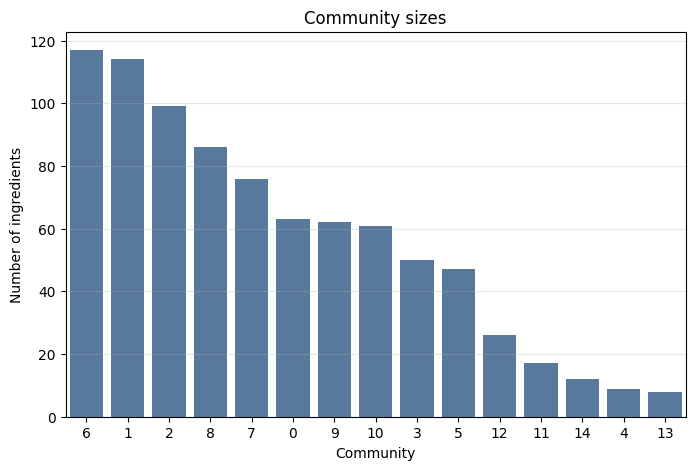

In [188]:
community_conductance = []
for community in communities:
    community_names = set(sparse_graph.vs[community]["_nx_name"])
    if 0 < len(community_names) < sparse_nx.number_of_nodes():
        community_conductance.append(conductance(sparse_nx, community_names, weight=edge_weight_name))

validation_metrics = pd.DataFrame([
    {"metric": "nodes", "value": sparse_graph.vcount()},
    {"metric": "edges", "value": sparse_graph.ecount()},
    {"metric": "communities", "value": len(communities)},
    {"metric": "modularity", "value": sparse_graph.modularity(membership, weights=edge_weight_name)},
    {"metric": "community_assortativity", "value": sparse_graph.assortativity_nominal(membership, directed=False)},
    {"metric": "degree_assortativity", "value": sparse_graph.assortativity_degree(directed=False)},
    {"metric": "global_clustering", "value": sparse_graph.transitivity_undirected()},
    {"metric": "average_local_clustering", "value": sparse_graph.transitivity_avglocal_undirected(mode="zero")},
    {"metric": "average_local_clustering_ppmi_weighted", "value": sparse_graph.transitivity_avglocal_undirected(mode="zero", weights=edge_weight_name)},
    {"metric": "mean_conductance", "value": sum(community_conductance) / len(community_conductance)},
])
display(validation_metrics)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=community_summary,
    x="community",
    y="size",
    order=community_summary["community"],
    color="#4C78A8",
    ax=ax,
)
ax.set_title("Community sizes")
ax.set_xlabel("Community")
ax.set_ylabel("Number of ingredients")
ax.grid(axis="y", alpha=0.3)

plt.show()

In [311]:
# Visualize PMI-based communities
sparse_graph.vs["label"] = sparse_graph.vs["_nx_name"]
sparse_graph.vs["weighted_degree"] = weighted_degree

def rgba_to_hex(rgba):
    r, g, b = rgba[:3]
    return "#{:02x}{:02x}{:02x}".format(
        round(255 * r), round(255 * g), round(255 * b)
    )

unique_communities = sorted(set(sparse_graph.vs["community"]))
community_palette = ig.RainbowPalette(n=len(unique_communities))
community_color_map = {
    community: rgba_to_hex(community_palette.get(i))
    for i, community in enumerate(unique_communities)
}
sparse_graph.vs["community_color"] = [community_color_map[community] for community in sparse_graph.vs["community"]]

MAX_COMMUNITY_LABELS = 15
label_communities = sorted(
    unique_communities,
    key=lambda community_id: sum(1 for v in sparse_graph.vs if v["community"] == community_id),
    reverse=True,
)[:MAX_COMMUNITY_LABELS]

community_representatives = {}
for community_id in label_communities:
    vertex_indices = [
        v.index
        for v in sparse_graph.vs
        if v["community"] == community_id
    ]
    representative = max(
        vertex_indices,
        key=lambda idx: sparse_graph.vs[idx]["weighted_degree"],
    )
    community_representatives[representative] = sparse_graph.vs[representative]["_nx_name"]

sparse_graph.vs["important_ingredient_label"] = [
    community_representatives.get(v.index, " ")
    for v in sparse_graph.vs
]
sparse_graph.vs["important_ingredient_label_size"] = [
    16 if v.index in community_representatives else 0
    for v in sparse_graph.vs
]

Sigma(
    sparse_graph,
    raw_node_color="community_color",
    node_label="important_ingredient_label",
    raw_node_label_size="important_ingredient_label_size",
    default_edge_color="rgba(128, 128, 128, 0.55)",
    clickable_edges=True,
    show_all_labels=True,
    label_rendered_size_threshold=0,
    label_density=1,
)

Sigma(ig.Graph with 847 nodes and 3,387 edges)

#### 2.5 Betweenness Centrality and Participation Coefficient

In [304]:
betweenness_distance_epsilon = 1e-9
betweenness_graph_nx = sparse_nx.copy()

for u, v, attrs in betweenness_graph_nx.edges(data=True):
    attrs["distance"] = np.exp(-float(attrs[edge_weight_name]))

vertex_betweenness = nx.betweenness_centrality(betweenness_graph_nx, weight="distance", normalized=True)

community_to_specific_cuisine = dict(zip(community_summary["community"], community_summary["specific_cuisine"]))
weighted_degree_by_ingredient = dict(zip(ingredient_communities["ingredient"], ingredient_communities["weighted_degree"]))

ingredient_rows = []
for node, attrs in betweenness_graph_nx.nodes(data=True):
    community_strengths = Counter()

    for neighbor, edge_attrs in betweenness_graph_nx[node].items():
        neighbor_community = betweenness_graph_nx.nodes[neighbor]["community"]
        community_strengths[neighbor_community] += float(edge_attrs[edge_weight_name])

    total_strength = sum(community_strengths.values())
    participation_coefficient = (
        1 - sum((strength / total_strength) ** 2 for strength in community_strengths.values())
        if total_strength > 0 else 0
    )

    ingredient_rows.append({
        "ingredient": node,
        "community": attrs["community"],
        "specific_cuisine": community_to_specific_cuisine.get(attrs["community"]),
        "degree": betweenness_graph_nx.degree(node),
        "weighted_degree": float(weighted_degree_by_ingredient.get(node, 0)),
        "recipe_count": int(attrs["recipe_count"]),
        "betweenness_centrality": vertex_betweenness[node],
        "participation_coefficient": participation_coefficient,
    })

num_display = 30
ingredient_betweenness = (
    pd.DataFrame(ingredient_rows)
    .sort_values(["betweenness_centrality", "participation_coefficient"], ascending=[False, False])
    .reset_index(drop=True)
)

betweenness_by_ingredient = dict(zip(ingredient_betweenness["ingredient"], ingredient_betweenness["betweenness_centrality"]))
participation_by_ingredient = dict(zip(ingredient_betweenness["ingredient"], ingredient_betweenness["participation_coefficient"]))

sparse_graph.vs["label"] = sparse_graph.vs["_nx_name"]
sparse_graph.vs["betweenness_centrality"] = [float(betweenness_by_ingredient[name]) for name in sparse_graph.vs["_nx_name"]]
sparse_graph.vs["participation_coefficient"] = [float(participation_by_ingredient[name]) for name in sparse_graph.vs["_nx_name"]]
sparse_graph.es["pmi_label"] = [round(float(value), 2) for value in sparse_graph.es["pmi"]]

print(f"Number of rows: {ingredient_betweenness.shape[0]} ({round(100 * num_display / ingredient_betweenness.shape[0], 2)}% displayed)")
display(ingredient_betweenness.head(num_display))

Number of rows: 847 (3.54% displayed)


,ingredient,community,specific_cuisine,degree,weighted_degree,recipe_count,betweenness_centrality,participation_coefficient
0,anaheim chile,1,thai,6,25.234882,5,0.088947,0.647156
1,thai chile,1,thai,27,83.164461,41,0.076131,0.252804
2,radishes,1,thai,11,41.453444,20,0.069180,0.275078
3,whole wheat pita pockets,10,greek,6,30.813712,6,0.060659,0.000000
4,corn tortillas,9,mexican,49,128.854375,93,0.057812,0.440898
5,cotija,9,mexican,8,35.646617,13,0.055781,0.463040
6,lean ground pork,2,cajun & creole,7,41.377182,3,0.054726,0.000000
7,water chestnuts,6,japanese,19,60.815658,25,0.053731,0.537397
8,sauce,10,greek,27,61.146559,71,0.050383,0.682017
9,baby spinach,3,italian,16,44.730180,49,0.049523,0.720352


In [312]:
unique_communities = sorted(set(sparse_graph.vs["community"]))
community_palette = ig.RainbowPalette(n=len(unique_communities))
community_color_map = {
    community: rgba_to_hex(community_palette.get(i))
    for i, community in enumerate(unique_communities)
}

sparse_graph.vs["community_color"] = [community_color_map[community] for community in sparse_graph.vs["community"]]

Sigma(
    sparse_graph,
    raw_node_color="community_color",
    node_size="betweenness_centrality",
    node_label="label",
    clickable_edges=True,
    label_density=3,
    default_edge_color="rgba(128, 128, 128, 0.55)"
)

Sigma(ig.Graph with 847 nodes and 3,387 edges)

#### 2.6 The Most Unique Recipe for Each Cuisine Based on Its Ingredients

In [ ]:
### TBD

## 3. Small and Giant Components

In [222]:
components = graph.connected_components(mode="weak")
giant_component = components.giant()
small_components = [c for c in components if len(c) < 20]

print("Original:", f"{graph.vcount()} vertices, {graph.ecount()} edges")
print("Giant:", f"{giant_component.vcount()} ({round(100 * giant_component.vcount() / graph.vcount(), 2)}% of total) vertices, {giant_component.ecount()} edges")

Original: 3611 vertices, 130439 edges
Giant: 3611 (100.0% of total) vertices, 130439 edges


In [223]:
vertices_small = []

for component in small_components:
    for v in component:
        print(v, graph.vs[v]["_nx_name"])
        vertices_small.append(v)
        # print(v, graph_nx.nodes[v])

In [28]:
# print(graph_nx.nodes)
print(graph.vertex_attributes())

['_nx_name', 'recipe_count', 'cuisines', 'courses', 'time_groups']


In [29]:
graph.vs[1320]["cuisines"]

'{"japanese": 3, "asian": 3}'

## 4. Cuisine-Specific Ingredients

In [232]:
cuisine_totals = Counter()
total_count = 0

for v_idx, v in enumerate(graph.vs):
    cuisines = parse_cuisines(v["cuisines"])

    if not cuisines:
        continue

    for cuisine, count in cuisines.items():
        cuisine_totals[cuisine] += count
        total_count += count

# P(cuisine)
p_cuisine = {
    cuisine: count / total_count
    for cuisine, count in cuisine_totals.items()
}

In [255]:
MIN_INGREDIENT_TOTAL = 10
MIN_CUISINE_INGREDIENT_COUNT = 5
MIN_CUISINE_TOTAL = 200
MIN_LIFT = 10

selected_vertices = []
dominant_cuisines = []
dominant_lifts = []

for v_idx, v in enumerate(graph.vs):
    cuisines = parse_cuisines(v["cuisines"])
    ingredient_total = sum(cuisines.values())

    if not cuisines or v_idx in vertices_small or ingredient_total < MIN_INGREDIENT_TOTAL:
        continue

    lifts = {}

    for cuisine, count in cuisines.items():
        if cuisine_totals[cuisine] < MIN_CUISINE_TOTAL or count < MIN_CUISINE_INGREDIENT_COUNT:
            continue
        
        # P(cuisine | ingredient)
        p_cuisine_given_ingredient = count / ingredient_total
        # lift = P(cuisine | ingredient) / P(cuisine)
        lifts[cuisine] = p_cuisine_given_ingredient / p_cuisine[cuisine]

    if not lifts:
        continue
    
    max_lift = max(lifts.values())
    if max_lift <= MIN_LIFT:
        continue

    winners = [cuisine for cuisine, lift_value in lifts.items() if lift_value == max_lift]
    print("Ingredient:", v["_nx_name"], "| Cuisine:", winners[0])

    if len(winners) == 1:
        selected_vertices.append(v.index)
        dominant_cuisines.append(winners[0])
        dominant_lifts.append(max_lift)

dominant_cuisine_lifts = {}

for cuisine, lift in zip(dominant_cuisines, dominant_lifts):
    dominant_cuisine_lifts.setdefault(cuisine, []).append(lift)

Ingredient: poultry seasoning | Cuisine: southern & soul food
Ingredient: diced celery | Cuisine: cajun & creole
Ingredient: tumeric | Cuisine: indian
Ingredient: cardamom pods | Cuisine: indian
Ingredient: pecorino romano cheese | Cuisine: italian
Ingredient: parmesan cheese | Cuisine: italian
Ingredient: gruyere cheese | Cuisine: french
Ingredient: raisins | Cuisine: irish
Ingredient: red lentils | Cuisine: moroccan
Ingredient: irish whiskey | Cuisine: irish
Ingredient: flaked coconut | Cuisine: hawaiian
Ingredient: black mustard seeds | Cuisine: indian
Ingredient: japanese rice | Cuisine: japanese
Ingredient: chuck roast | Cuisine: hungarian
Ingredient: poblano chiles | Cuisine: mexican
Ingredient: yeast | Cuisine: portuguese
Ingredient: cajun seasoning | Cuisine: cajun & creole
Ingredient: mashed potatoes | Cuisine: irish
Ingredient: arborio rice | Cuisine: spanish
Ingredient: fresh orange juice | Cuisine: cuban
Ingredient: enchilada sauce | Cuisine: mexican
Ingredient: togarashi |

In [263]:
dominance_count = Counter(dominant_cuisines)

cuisine_dominance_stats = pd.DataFrame([
    {
        "cuisine": cuisine,
        "dominance_count": dominance_count.get(cuisine, 0),
        "overall_cuisine_count": cuisine_totals[cuisine],
        "dominance_percent": 100 * dominance_count.get(cuisine, 0) / cuisine_totals[cuisine],
        "mean_dominant_lift": (
            sum(dominant_cuisine_lifts.get(cuisine, [])) / len(dominant_cuisine_lifts[cuisine])
            if cuisine in dominant_cuisine_lifts else 0
        ),
    }
    for cuisine in sorted(cuisine_totals)
])

cuisine_dominance_stats = cuisine_dominance_stats.sort_values("mean_dominant_lift", ascending=False).reset_index(drop=True)

cuisine_dominance_stats.head(10)

,cuisine,dominance_count,overall_cuisine_count,dominance_percent,mean_dominant_lift
0,hawaiian,10,1518,0.658762,28.725436
1,irish,12,1569,0.764818,26.462751
2,moroccan,11,2260,0.486726,22.539992
3,barbecue,3,2457,0.122100,21.457878
4,swedish,10,1382,0.723589,20.408916
5,french,21,2756,0.761974,17.054574
6,southwestern,14,2196,0.637523,16.144137
7,portuguese,9,2487,0.361882,16.122734
8,italian,30,3935,0.762389,15.989903
9,indian,23,3717,0.618779,15.693738


In [ ]:
TOP_K_INGREDIENTS = 5

cuisine_specific_ingredients = pd.DataFrame({
    "ingredient": [graph.vs[v]["_nx_name"] for v in selected_vertices],
    "cuisine": dominant_cuisines,
    "lift": dominant_lifts,
})

top_lift_ingredients_by_cuisine = (
    cuisine_specific_ingredients
    .sort_values(["cuisine", "lift"], ascending=[True, False])
    .groupby("cuisine", as_index=False)
    .head(TOP_K_INGREDIENTS)
    .groupby("cuisine", as_index=False)
    .agg(ingredients=("ingredient", list))
    .sort_values("cuisine")
    .reset_index(drop=True)
)

pd.set_option("display.max_colwidth", None)
display(top_lift_ingredients_by_cuisine)

,cuisine,ingredients
0,barbecue,"[swordfish, lettuce leaves, hamburger buns]"
1,cajun & creole,"[andouille sausage, creole seasoning, creole mustard, cajun seasoning, okra]"
2,chinese,"[cooking wine, shaoxing wine, chinese black vinegar, chinese rice wine, chinese five-spice powder]"
3,cuban,"[pimento stuffed green olives, club soda, light rum, simple syrup, mint sprigs]"
4,french,"[grated gruyère cheese, gruyere cheese, almond meal, cognac, vanilla beans]"
5,german,"[sauerkraut, whole grain mustard, apples, red cabbage, granny smith apples]"
6,greek,"[tzatziki sauce, greek seasoning, feta cheese crumbles, pita chips, plain greek yogurt]"
7,hawaiian,"[crushed pineapple, pineapple slices, pineapple, pineapple chunks, pineapple juice]"
8,hungarian,"[hungarian paprika, beef stew meat, low-fat sour cream, round steaks, chuck]"
9,indian,"[ghee, coriander powder, mustard seeds, garam masala, cardamom pods]"


In [276]:
h = graph.subgraph(selected_vertices)
h.vs["dominant_cuisine"] = dominant_cuisines
h.vs["dominant_lift"] = dominant_lifts

selected_ingredient_names = [graph.vs[v]["_nx_name"] for v in selected_vertices]
h_nx = graph_nx.subgraph(selected_ingredient_names).copy()

for ingredient, cuisine, lift in zip(selected_ingredient_names, dominant_cuisines, dominant_lifts):
    h_nx.nodes[ingredient]["dominant_cuisine"] = cuisine
    h_nx.nodes[ingredient]["dominant_lift"] = lift
    h_nx.nodes[ingredient]["label"] = ingredient


# h_components = h.connected_components(mode="weak")
# h_giant = h_components.giant()

# print("Selected vertices:", h_giant.vcount())
# print("Edges:", h_giant.ecount())

In [279]:
def rgba_to_hex(rgba):
    r, g, b = rgba[:3]
    return "#{:02x}{:02x}{:02x}".format(
        round(255 * r), round(255 * g), round(255 * b)
    )

unique_cuisines = sorted(set(dominant_cuisines))
palette = ig.RainbowPalette(n=len(unique_cuisines))
color_map = {
    cuisine: rgba_to_hex(palette.get(i))
    for i, cuisine in enumerate(unique_cuisines)
}
vertex_colors = [color_map[cuisine] for cuisine in dominant_cuisines]

h.vs["dominant_cuisine_color"] = vertex_colors

In [288]:
# MAX_CUISINE_LABELS = 10
# label_cuisines = sorted(
#     set(h.vs["dominant_cuisine"]),
#     key=lambda cuisine: sum(1 for v in h.vs if v["dominant_cuisine"] == cuisine),
#     reverse=True,
# )[:MAX_CUISINE_LABELS]

# dominant_cuisine_representatives = {}
# for cuisine in label_cuisines:
#     vertex_indices = [
#         v.index
#         for v in h.vs
#         if v["dominant_cuisine"] == cuisine
#     ]
#     representative = max(
#         vertex_indices,
#         key=lambda idx: h.vs[idx]["dominant_lift"],
#     )
#     dominant_cuisine_representatives[representative] = h.vs[representative]["_nx_name"]

# h.vs["dominant_cuisine_label"] = [
#     dominant_cuisine_representatives.get(v.index, " ")
#     for v in h.vs
# ]
# h.vs["dominant_cuisine_label_size"] = [
#     11 if v.index in dominant_cuisine_representatives else 0
#     for v in h.vs
# ]

Sigma(
    h,
    raw_node_color="dominant_cuisine_color",
    node_size="dominant_lift",
    node_label="_nx_name",
    edge_size="recipe_count",
    edge_label="recipe_count",
    clickable_edges=True,
    default_edge_color="rgba(128, 128, 128, 0.55)",
)

Sigma(ig.Graph with 305 nodes and 3,604 edges)

## 5. Logistic Regression: Ingredients -> Cuisine

In [6]:
cuisine_df = pd.read_csv("https://raw.githubusercontent.com/conwayyao/Recipe-Analysis/master/CuisineAnalyzer/cuisinedata/cuisine_data.csv").drop(columns=["Unnamed: 0"])

In [7]:
# cuisine_df

In [4]:
def parse_label_list(value):
    if isinstance(value, list):
        return [str(label).strip().lower() for label in value if str(label).strip()]
    if pd.isna(value) or value == "[]":
        return []

    try:
        parsed = ast.literal_eval(value)
    except (ValueError, SyntaxError):
        parsed = str(value).strip("[]").split(",")

    if isinstance(parsed, str):
        parsed = [parsed]

    return [str(label).strip().lower().strip("'\"") for label in parsed if str(label).strip()]

def count_list_labels(df, column):
    labels = df[column].apply(parse_label_list).explode()
    return labels.dropna().value_counts().rename_axis(column).reset_index(name="recipe_count")


In [242]:
course_label_counts = count_list_labels(cuisine_df, "course")
cuisine_label_counts = count_list_labels(cuisine_df, "cuisine")

print("Course labels:", len(course_label_counts))
# display(course_label_counts)

print("Cuisine labels:", len(cuisine_label_counts))
# display(cuisine_label_counts)

Course labels: 13
Cuisine labels: 26


In [ ]:
MIN_CUISINE_EXAMPLES = 100
RANDOM_STATE = 42

In [11]:
logreg_df = cuisine_df.copy()
logreg_df["ingredient_labels"] = logreg_df["ingredients"].apply(parse_label_list)
logreg_df["cuisine_labels"] = logreg_df["cuisine"].apply(parse_label_list)
logreg_df["target_cuisine"] = logreg_df["cuisine_labels"].apply(lambda labels: labels[0] if labels else pd.NA)

logreg_df = logreg_df[logreg_df["ingredient_labels"].map(len).gt(0) & logreg_df["target_cuisine"].notna()].copy()

eligible_cuisines = logreg_df["target_cuisine"].value_counts().loc[lambda counts: counts >= MIN_CUISINE_EXAMPLES].index
logreg_df = logreg_df[logreg_df["target_cuisine"].isin(eligible_cuisines)].reset_index(drop=True)

In [ ]:
pca_vectorizer = TfidfVectorizer(analyzer=lambda tokens: tokens, lowercase=False)
tfidf_matrix = pca_vectorizer.fit_transform(logreg_df["ingredient_labels"])

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coordinates = pca.fit_transform(tfidf_matrix.toarray())

pca_df = pd.DataFrame({
    "pca_1": pca_coordinates[:, 0],
    "pca_2": pca_coordinates[:, 1],
    "cuisine": logreg_df["target_cuisine"],
    "dish_name": logreg_df["recipeName"].fillna("Unknown dish").astype(str),
})

fig = px.scatter(
    pca_df,
    x="pca_1",
    y="pca_2",
    color="cuisine",
    hover_name="dish_name",
    hover_data={
        "cuisine": True,
        "dish_name": False,
    },
    labels={"cuisine": "Cuisine"},
    title="TF-IDF PCA projection by cuisine",
)
fig.update_traces(marker={"size": 5, "opacity": 0.65})
fig.update_layout(
    showlegend=True,
    legend_title_text="Cuisine",
    legend={"itemsizing": "constant"},
    height=650,
)
fig.show()

In [11]:
X, y = logreg_df["ingredient_labels"], logreg_df["target_cuisine"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

In [12]:
split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "recipes": [len(X_train), len(X_test)],
    "classes": [y_train.nunique(), y_test.nunique()],
})

print("Eligible cuisines:", len(eligible_cuisines))
display(logreg_df["target_cuisine"].value_counts().rename_axis("cuisine").reset_index(name="recipe_count").head(5))
display(split_summary)

Eligible cuisines: 24


,cuisine,recipe_count
0,american,770
1,asian,713
2,greek,552
3,thai,518
4,cajun & creole,494


,split,recipes,classes
0,train,6898,24
1,test,1725,24


In [13]:
def evaluate_classifier(model, X_eval, y_eval, split_name, feature_mode):
    y_pred = model.predict(X_eval)
    return {
        "feature_mode": feature_mode,
        "split": split_name,
        "accuracy": accuracy_score(y_eval, y_pred),
        "macro_f1": f1_score(y_eval, y_pred, average="macro"),
        "weighted_f1": f1_score(y_eval, y_pred, average="weighted"),
    }

In [14]:
feature_modes = {
    "tfidf": TfidfVectorizer(analyzer=lambda tokens: tokens, lowercase=False),
    "multi_hot": CountVectorizer(analyzer=lambda tokens: tokens, lowercase=False, binary=True),
}

param_distributions = {"model__C": np.logspace(-3, 20, 300)}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [15]:
model_searches = {}
metric_rows = []
classification_reports = {}

for feature_mode, vectorizer in feature_modes.items():
    pipeline = Pipeline([
        ("features", vectorizer),
        ("model", LogisticRegression(
            penalty="l2",
            class_weight="balanced",
            max_iter=5000,
            solver="lbfgs",
            random_state=RANDOM_STATE,
        )),
    ])

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_distributions,
        n_iter=12,
        scoring="f1_macro",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)
    model_searches[feature_mode] = search

    metric_rows.append({
        "feature_mode": feature_mode,
        "split": "train_cv",
        "accuracy": np.nan,
        "macro_f1": search.best_score_,
        "weighted_f1": np.nan,
        "best_C": search.best_params_["model__C"],
    })
    row = evaluate_classifier(search.best_estimator_, X_test, y_test, "test", feature_mode)
    row["best_C"] = search.best_params_["model__C"]
    metric_rows.append(row)
    classification_reports[(feature_mode, "test")] = classification_report(
        y_test,
        search.best_estimator_.predict(X_test),
        output_dict=True,
        zero_division=0,
    )

c:\Users\aleks\OneDrive\Desktop\Studying\University projects\vos-proj-eda\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\aleks\OneDrive\Desktop\Studying\University projects\vos-proj-eda\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [16]:
logreg_metrics = pd.DataFrame(metric_rows)
display(logreg_metrics)

,feature_mode,split,accuracy,macro_f1,weighted_f1,best_C
0,tfidf,train_cv,NaN,0.666540,NaN,24.24462
1,tfidf,test,0.702609,0.692524,0.703074,24.24462
2,multi_hot,train_cv,NaN,0.641384,NaN,24.24462
3,multi_hot,test,0.671304,0.658301,0.672308,24.24462


In [17]:
best_feature_mode = logreg_metrics[logreg_metrics["split"] == "train_cv"].sort_values("macro_f1", ascending=False).iloc[0]["feature_mode"]
best_logreg_model = model_searches[best_feature_mode].best_estimator_
print("Best feature mode by train CV macro-F1:", best_feature_mode)
print("Best C:", model_searches[best_feature_mode].best_params_["model__C"])

Best feature mode by train CV macro-F1: tfidf
Best C: 24.244620170823307


In [18]:
test_report_df = pd.DataFrame(classification_reports[(best_feature_mode, "test")]).T
display(test_report_df)

,precision,recall,f1-score,support
american,0.561644,0.532468,0.546667,154.000000
asian,0.718519,0.678322,0.697842,143.000000
barbecue,0.464286,0.440678,0.452174,59.000000
cajun & creole,0.875000,0.848485,0.861538,99.000000
chinese,0.629630,0.666667,0.647619,51.000000
cuban,0.640000,0.680851,0.659794,47.000000
french,0.662338,0.708333,0.684564,72.000000
german,0.533333,0.689655,0.601504,58.000000
greek,0.757282,0.709091,0.732394,110.000000
hawaiian,0.750000,0.750000,0.750000,36.000000


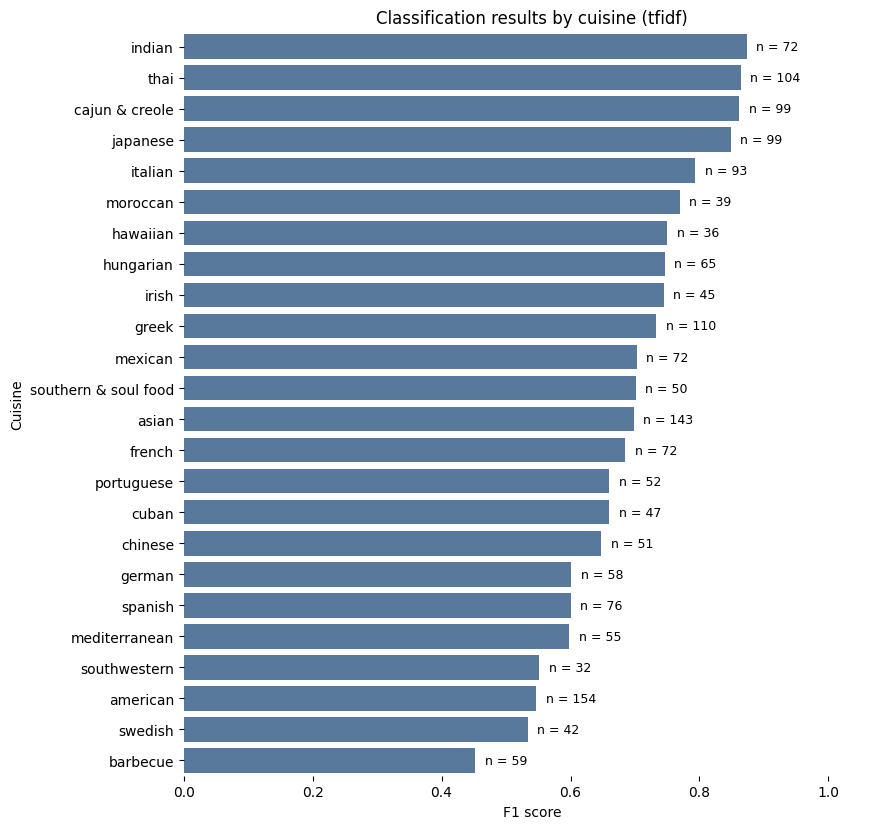

In [20]:
class_labels = best_logreg_model.named_steps["model"].classes_
classification_result_df = (
    test_report_df.loc[class_labels, ["f1-score", "support"]]
    .rename(columns={"f1-score": "f1_score"})
    .assign(support=lambda df: df["support"].astype(int))
    .sort_values("f1_score", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, max(6, 0.35 * len(classification_result_df))))
sns.barplot(
    data=classification_result_df.reset_index(names="cuisine"),
    x="f1_score",
    y="cuisine",
    color="#4C78A8",
    ax=ax,
)

ax.set_xlim(0, 1.08)
ax.set_xlabel("F1 score")
ax.set_ylabel("Cuisine")
ax.set_title(f"Classification results by cuisine ({best_feature_mode})")

for patch, support in zip(ax.patches, classification_result_df["support"]):
    width = patch.get_width()
    y_position = patch.get_y() + patch.get_height() / 2
    if width < 0.92:
        ax.text(width + 0.015, y_position, f"n = {support}", va="center", ha="left", fontsize=9)
    else:
        ax.text(width - 0.015, y_position, f"n = {support}", va="center", ha="right", fontsize=9, color="white")

sns.despine(left=True, bottom=True)
plt.tight_layout()

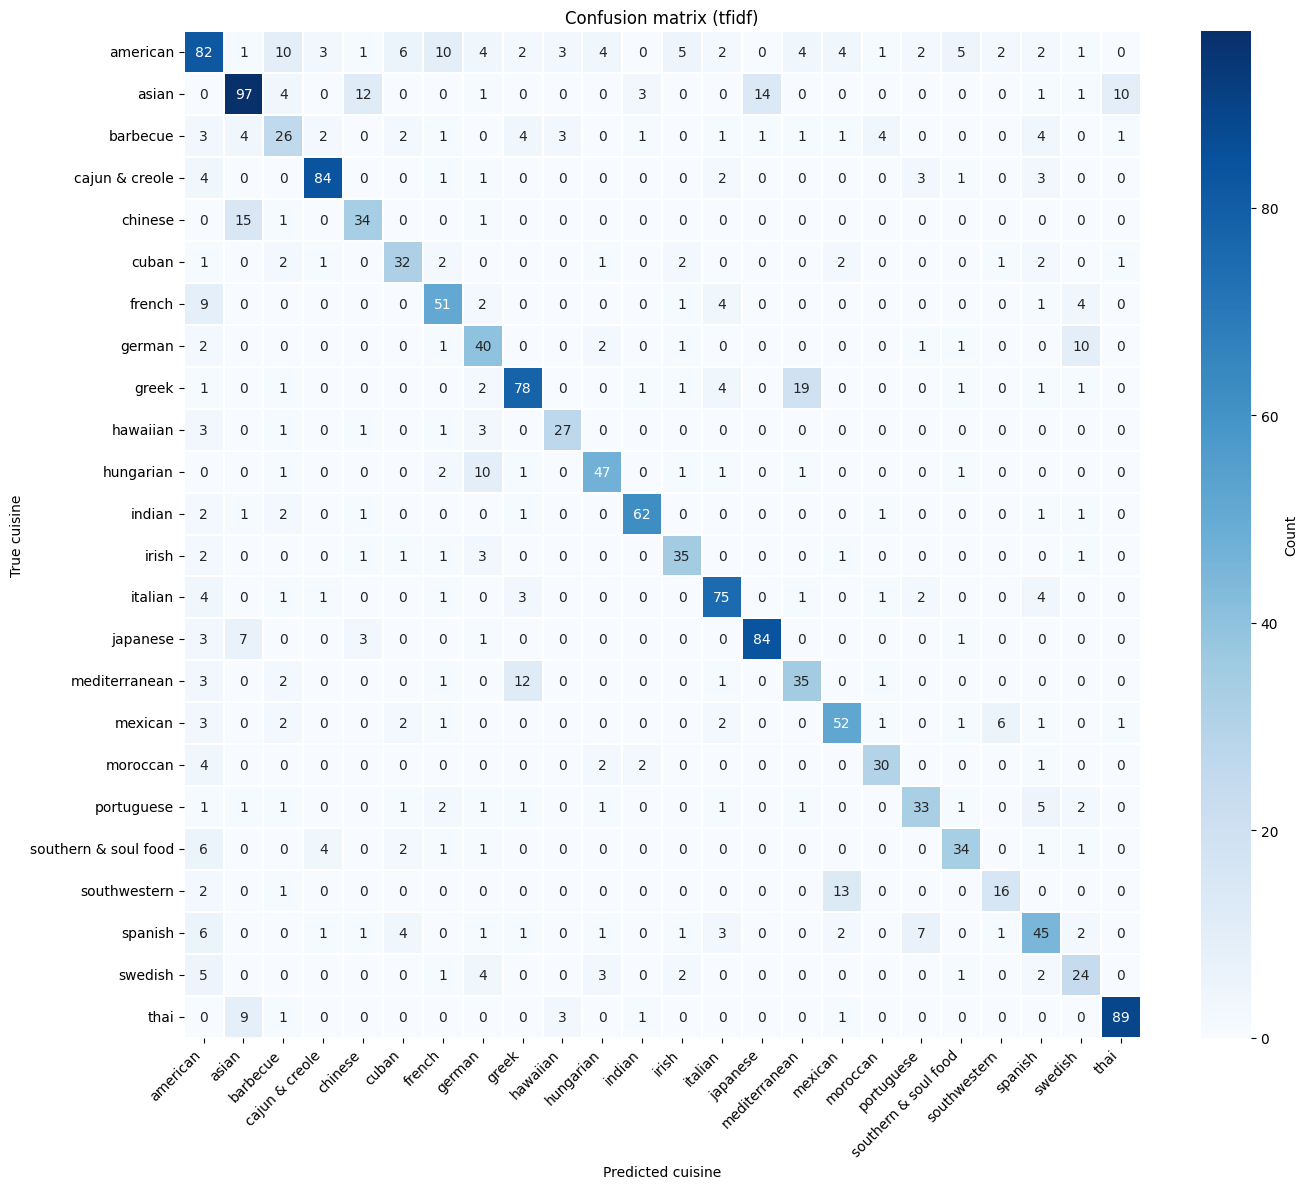

In [21]:
confusion_labels = best_logreg_model.named_steps["model"].classes_
y_test_pred = best_logreg_model.predict(X_test)
confusion_counts = confusion_matrix(y_test, y_test_pred, labels=confusion_labels)
confusion_df = pd.DataFrame(confusion_counts, index=confusion_labels, columns=confusion_labels)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    confusion_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Count"},
    ax=ax,
)
ax.set_xlabel("Predicted cuisine")
ax.set_ylabel("True cuisine")
ax.set_title(f"Confusion matrix ({best_feature_mode})")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

In [ ]:
def logistic_regression_feature_coefficients(estimator, top_n=10):
    vectorizer = estimator.named_steps["features"]
    model = estimator.named_steps["model"]
    feature_names = np.array(vectorizer.get_feature_names_out())
    
    classes = model.classes_
    coefs = model.coef_

    if coefs.shape[0] == 1:
        class_coef_pairs = [(classes[1], coefs[0]), (classes[0], -coefs[0])]
    else:
        class_coef_pairs = list(zip(classes, coefs))

    rows = []
    for cuisine, coef in class_coef_pairs:
        top_indices = np.argsort(coef)[-top_n:][::-1]
        bottom_indices = np.argsort(coef)[:top_n]

        for rank, idx in enumerate(top_indices, start=1):
            rows.append({
                "feature_mode": best_feature_mode,
                "cuisine": cuisine,
                "direction": "top_positive",
                "rank": rank,
                "ingredient": feature_names[idx],
                "coefficient": coef[idx],
            })
        for rank, idx in enumerate(bottom_indices, start=1):
            rows.append({
                "feature_mode": best_feature_mode,
                "cuisine": cuisine,
                "direction": "top_negative",
                "rank": rank,
                "ingredient": feature_names[idx],
                "coefficient": coef[idx],
            })

    return pd.DataFrame(rows)


In [29]:
def get_top_ingredients(ingredient_coefficients: pd.DataFrame, cuisine: str):
    cuisine_coefficients = ingredient_coefficients[ingredient_coefficients["cuisine"] == cuisine]
    print("=" * 120)
    print("Cuisine:", cuisine)
    print("Top positive ingredients")
    display(cuisine_coefficients[cuisine_coefficients["direction"] == "top_positive"][["rank", "ingredient", "coefficient"]])
    print("Top negative ingredients")
    display(cuisine_coefficients[cuisine_coefficients["direction"] == "top_negative"][["rank", "ingredient", "coefficient"]])

In [26]:
logreg_df['target_cuisine'].unique()

<StringArray>
['southern & soul food',             'american',             'barbecue',
       'cajun & creole',              'spanish',         'southwestern',
                'irish',              'italian',              'chinese',
                'asian',             'japanese',                 'thai',
               'indian',             'hawaiian',              'mexican',
        'mediterranean',                'cuban',               'french',
               'german',                'greek',            'hungarian',
             'moroccan',           'portuguese',              'swedish']
Length: 24, dtype: str

In [27]:
top_n_coefficients = 10
ingredient_coefficients = logistic_regression_feature_coefficients(best_logreg_model, top_n=top_n_coefficients)

In [42]:
get_top_ingredients(ingredient_coefficients=ingredient_coefficients, cuisine="barbecue")

Cuisine: barbecue
Top positive ingredients


,rank,ingredient,coefficient
40,1,barbecue sauce,6.531404
41,2,bbq sauce,6.139407
42,3,boneless skinless chicken breast halves,6.064625
43,4,swordfish,5.752898
44,5,marinade,5.635089
45,6,lobster tails,5.405508
46,7,chili sauce,5.165885
47,8,freshly ground black pepper,5.109996
48,9,bamboo shoots,4.915013
49,10,broiler-fryer chicken,4.910712


Top negative ingredients


,rank,ingredient,coefficient
50,1,all-purpose flour,-4.934832
51,2,corn starch,-4.652593
52,3,onions,-4.290217
53,4,eggs,-4.287383
54,5,dry white wine,-4.077848
55,6,flour,-3.833475
56,7,carrots,-3.783802
57,8,milk,-3.741444
58,9,yellow onion,-3.556664
59,10,chicken stock,-3.527071


In [35]:
# for cuisine_label in logreg_df['target_cuisine'].unique():
#     get_top_ingredients(ingredient_coefficients=ingredient_coefficients, cuisine=cuisine_label)

## 6. Ingredients -> Cooking Time